In [1]:
# Importing dependencies

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import keras
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras import *
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.callbacks import Callback
import keras_cv

BATCH_SIZE = 20
GLOBAL_CLIPNORM = 10.0

AUTO = tf.data.AUTOTUNE

In [2]:
# a function for converting txt file to list
def parse_txt_annot(img_path, txt_path):
    img = cv2.imread(img_path)
    w = int(img.shape[0])
    h = int(img.shape[1])

    file_label = open(txt_path, "r")
    lines = file_label.read().split('\n')
    
    boxes = []
    classes = []

    for i in range(0, int(len(lines))):
        if lines[i] == '':
            continue
        else:
            objbud=lines[i].split(' ')
            class_ = int(objbud[0])

            x1 = float(objbud[1])
            y1 = float(objbud[2])
            w1 = float(objbud[3])
            h1 = float(objbud[4])

            xmin = int((x1*w) - (w1*w)/2.0)
            ymin = int((y1*h) - (h1*h)/2.0)
            xmax = int((x1*w) + (w1*w)/2.0)
            ymax = int((y1*h) + (h1*h)/2.0)

            boxes.append([xmin ,ymin ,xmax ,ymax])
            classes.append(class_)
    
    return img_path, classes, boxes

# a function for creating file paths list 
def create_paths_list(path):
    full_path = []
    images = sorted(os.listdir(path))
    
    for i in images:
        full_path.append(os.path.join(path, i))
        
    return full_path

class_ids = ['note', 'robot']
class_mapping = dict(zip(range(len(class_ids)), class_ids))

In [3]:
def creating_files(img_files_paths, annot_files_paths):
    
    img_files = create_paths_list(img_files_paths)
    annot_files = create_paths_list(annot_files_paths)
    
    image_paths = []
    bbox = []
    classes = []
    
    for i in range(0,len(img_files)):
        image_path_, classes_, bbox_ = parse_txt_annot(img_files[i], annot_files[i])
        image_paths.append(image_path_)
        bbox.append(bbox_)
        classes.append(classes_)
        
    image_paths = tf.ragged.constant(image_paths)
    bbox = tf.ragged.constant(bbox)
    classes = tf.ragged.constant(classes)
    
    return image_paths, classes, bbox

In [4]:
train_img_paths, train_classes, train_bboxes = creating_files('/kaggle/input/frc-yolo-2/train/images', '/kaggle/input/frc-yolo-2/train/labels')
print('Train finished')
valid_img_paths, valid_classes, valid_bboxes = creating_files('/kaggle/input/frc-yolo-2/valid/images', '/kaggle/input/frc-yolo-2/valid/labels')
print('Valid finished')
test_img_paths, test_classes, test_bboxes = creating_files('/kaggle/input/frc-yolo-2/test/images', '/kaggle/input/frc-yolo-2/test/labels')
print('Test finished')

Train finished
Valid finished
Test finished


In [8]:
# reading and resizing images
def img_preprocessing(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32) 
    
    return img

tf.random.set_global_generator(tf.random.Generator.from_seed(1))

resizing = keras_cv.layers.JitteredResize(
    target_size=(640, 640),
    scale_factor=(0.75, 1.3),
    bounding_box_format="xyxy")

# loading dataset
def load_ds(img_paths, classes, bbox):
    img = img_preprocessing(img_paths)

    bounding_boxes = {
        "classes": tf.cast(classes, dtype=tf.float32),
        "boxes": bbox }
    
    return {"images": img, "bounding_boxes": bounding_boxes}

def dict_to_tuple(inputs):
    return inputs["images"], inputs["bounding_boxes"]

In [ ]:
# Creating dataset loaders and tf.datasets
train_loader = tf.data.Dataset.from_tensor_slices((train_img_paths, train_classes, train_bboxes))

train_dataset = (train_loader
                 .map(load_ds, num_parallel_calls = AUTO)
                 .shuffle(BATCH_SIZE*10)
                 .ragged_batch(BATCH_SIZE, drop_remainder = True)
                 .map(resizing, num_parallel_calls = AUTO)
                 .map(dict_to_tuple, num_parallel_calls = AUTO)
                 .prefetch(AUTO))


valid_loader = tf.data.Dataset.from_tensor_slices((valid_img_paths, valid_classes, valid_bboxes))

valid_dataset = (valid_loader
                 .map(load_ds, num_parallel_calls = AUTO)
                 .ragged_batch(BATCH_SIZE, drop_remainder = True)
                 .map(resizing, num_parallel_calls = AUTO)
                 .map(dict_to_tuple, num_parallel_calls = AUTO)
                 .prefetch(AUTO))


test_loader = tf.data.Dataset.from_tensor_slices((test_img_paths, test_classes, test_bboxes))

test_dataset = (test_loader
                .map(load_ds, num_parallel_calls = AUTO)
                .ragged_batch(BATCH_SIZE, drop_remainder = True)
                .map(resizing, num_parallel_calls = AUTO)
                .map(dict_to_tuple, num_parallel_calls = AUTO)
                .prefetch(AUTO))

In [ ]:
# a function to visualize samples from a dataset
def visualize_dataset(inputs, value_range, rows, cols, bounding_box_format):
    inputs = next(iter(inputs.take(1)))
    images, bounding_boxes = inputs[0], inputs[1]
    
    keras_cv.visualization.plot_bounding_box_gallery(
        images,
        value_range=value_range,
        rows=rows,
        cols=cols,
        y_true=bounding_boxes,
        scale = 8,
        font_scale = 0.8,
        line_thickness=2,
        dpi = 100,
        bounding_box_format=bounding_box_format,
        class_mapping=class_mapping,
        true_color = (192, 57, 43))

In [ ]:
# examples images and annotations from training daatset
visualize_dataset(train_dataset, bounding_box_format="xyxy", value_range=(0, 255), rows=2, cols=2)

In [6]:
# creating pre-trained model backbone with coco weights
backbone = keras_cv.models.YOLOV8Backbone.from_preset("yolo_v8_xs_backbone_coco")

Attaching 'config.json' from model 'keras/yolov8/keras/yolo_v8_xs_backbone_coco/2' to your Kaggle notebook...
Attaching 'config.json' from model 'keras/yolov8/keras/yolo_v8_xs_backbone_coco/2' to your Kaggle notebook...
Attaching 'model.weights.h5' from model 'keras/yolov8/keras/yolo_v8_xs_backbone_coco/2' to your Kaggle notebook...
/opt/conda/lib/python3.10/site-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids
/opt/conda/lib/python3.10/site-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `layer.updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids


In [7]:
YOLOV8_model = keras_cv.models.YOLOV8Detector(num_classes=len(class_mapping),
                                              bounding_box_format="xyxy",
                                              backbone=backbone, fpn_depth=1)

optimizer = Adam(learning_rate=0.001, global_clipnorm = GLOBAL_CLIPNORM)

YOLOV8_model.compile(optimizer = optimizer, classification_loss = 'binary_crossentropy', box_loss = 'ciou')

In [33]:
class_ids = ['note', 'robot']
class_mapping = dict(zip(range(len(class_ids)), class_ids))

In [ ]:
lowest_val_box_loss = [9999999.999]
lowest_val_class_loss = [99999999.999]

for i in range(100):
    YOLOV8_model = keras.saving.load_model('/kaggle/working/yolo_model.keras')
    YOLOV8_model.compile(optimizer = optimizer, classification_loss = 'binary_crossentropy', box_loss = 'ciou')
    hist = YOLOV8_model.fit(train_dataset, validation_data = valid_dataset, epochs = 1)
    if(hist.history['val_box_loss'][0] < last_val_box_loss and hist.history['val_class_loss'] < lowest_val_class_loss):
        YOLOV8_model.save("yolo_model.keras")

In [ ]:
fig, axs = plt.subplots(1,3, figsize = (18,5), dpi = 130)

axs[0].grid(linestyle="dashdot")
axs[0].set_title("Loss")
axs[0].plot(hist.history['loss'][1:])
axs[0].plot(hist.history['val_loss'][1:])
axs[0].legend(["train", "validataion"])

axs[1].grid(linestyle="dashdot")
axs[1].set_title("Box Loss")
axs[1].plot(hist.history['box_loss'])
axs[1].plot(hist.history['val_box_loss'])
axs[1].legend(["train",  "validataion"])

axs[2].grid(linestyle="dashdot")
axs[2].set_title("Class Loss")
axs[2].plot(hist.history['class_loss'][1:])
axs[2].plot(hist.history['val_class_loss'][1:])
axs[2].legend(["train",  "validataion"])

In [31]:
def visualize_predict_detections(model, dataset, bounding_box_format):
    images, y_true = next(iter(dataset.take(1)))
    
    y_pred = model.predict(images)
    y_pred = keras_cv.bounding_box.to_ragged(y_pred)
    
    keras_cv.visualization.plot_bounding_box_gallery(
        images,
        value_range=(0, 255),
        bounding_box_format=bounding_box_format,
        y_true=y_true,
        y_pred=y_pred,
        true_color = (192, 57, 43),
        pred_color=(255, 235, 59),
        scale = 4,
        font_scale = 0.8,
        line_thickness=2,
        dpi = 100,
        rows=4,
        cols=4,
        show=True,
        class_mapping=class_mapping,
    )

In [85]:
!rm -rf /kaggle/working/*

In [90]:
!zip -r file.zip /kaggle/working/YOLOV8_model

  adding: kaggle/working/YOLOV8_model/ (stored 0%)
  adding: kaggle/working/YOLOV8_model/variables/ (stored 0%)
  adding: kaggle/working/YOLOV8_model/variables/variables.index (deflated 78%)
  adding: kaggle/working/YOLOV8_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: kaggle/working/YOLOV8_model/fingerprint.pb (stored 0%)
  adding: kaggle/working/YOLOV8_model/assets/ (stored 0%)
  adding: kaggle/working/YOLOV8_model/saved_model.pb (deflated 92%)


In [89]:
tf.saved_model.save(YOLOV8_model, '/kaggle/working/YOLOV8_model')

converter = tf.lite.TFLiteConverter.from_saved_model('/kaggle/working/')
converter.target_spec.supported_ops = [
 tf.lite.OpsSet.TFLITE_BUILTINS, # enable TensorFlow Lite ops.
 tf.lite.OpsSet.SELECT_TF_OPS # enable TensorFlow ops.
]
tflite_model = converter.convert()
open("converted_model.tflite", "wb").write(tflite_model)

/opt/conda/lib/python3.10/site-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids
/opt/conda/lib/python3.10/site-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `layer.updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids
/opt/conda/lib/python3.10/site-packages/keras_cv/src/models/task.py:43: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids
/opt/conda/lib/python3.10/site-packages/keras_cv/src/models/task.py:4

99778144

In [87]:
! pip install edgetpu_compiler

ERROR: Could not find a version that satisfies the requirement edgetpu_compiler (from versions: none)
ERROR: No matching distribution found for edgetpu_compiler


In [78]:
from tensorflow.lite.python.interpreter import Interpreter

# Get list of all images in train directory
image_path = '/content/images/train'

jpg_file_list = glob.glob(image_path + '/*.jpg')
JPG_file_list = glob.glob(image_path + '/*.JPG')
png_file_list = glob.glob(image_path + '/*.png')
bmp_file_list = glob.glob(image_path + '/*.bmp')

quant_image_list = jpg_file_list + JPG_file_list + png_file_list + bmp_file_list

In [79]:
interpreter = Interpreter(model_path='/kaggle/working/model.tflite') # PATH_TO_MODEL is defined in Step 7 above
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
height = input_details[0]['shape'][1]
width = input_details[0]['shape'][2]

import random

def representative_data_gen():
    dataset_list = quant_image_list
    quant_num = 300
    
    for i in range(quant_num):
        pick_me = random.choice(dataset_list)
        image = tf.io.read_file(pick_me)

        if pick_me.endswith('.jpg') or pick_me.endswith('.JPG'):
            image = tf.io.decode_jpeg(image, channels=3)
        elif pick_me.endswith('.png'):
            image = tf.io.decode_png(image, channels=3)
        elif pick_me.endswith('.bmp'):
            image = tf.io.decode_bmp(image, channels=3)

        image = tf.image.resize(image, [width, height])  # TO DO: Replace 300s with an automatic way of reading network input size
        image = tf.cast(image / 255., tf.float32)
        image = tf.expand_dims(image, 0)
        yield [image]

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


RuntimeError: tensorflow/lite/kernels/concatenation.cc:159 t->dims->data[d] != t0->dims->data[d] (1 != 2)Node number 190 (CONCATENATION) failed to prepare.Failed to apply the default TensorFlow Lite delegate indexed at 0.

In [ ]:
YOLOV8_model = keras.saving.load_model('/kaggle/working/yolo_model.keras')

1/1 [==============================] - 22s 22s/step


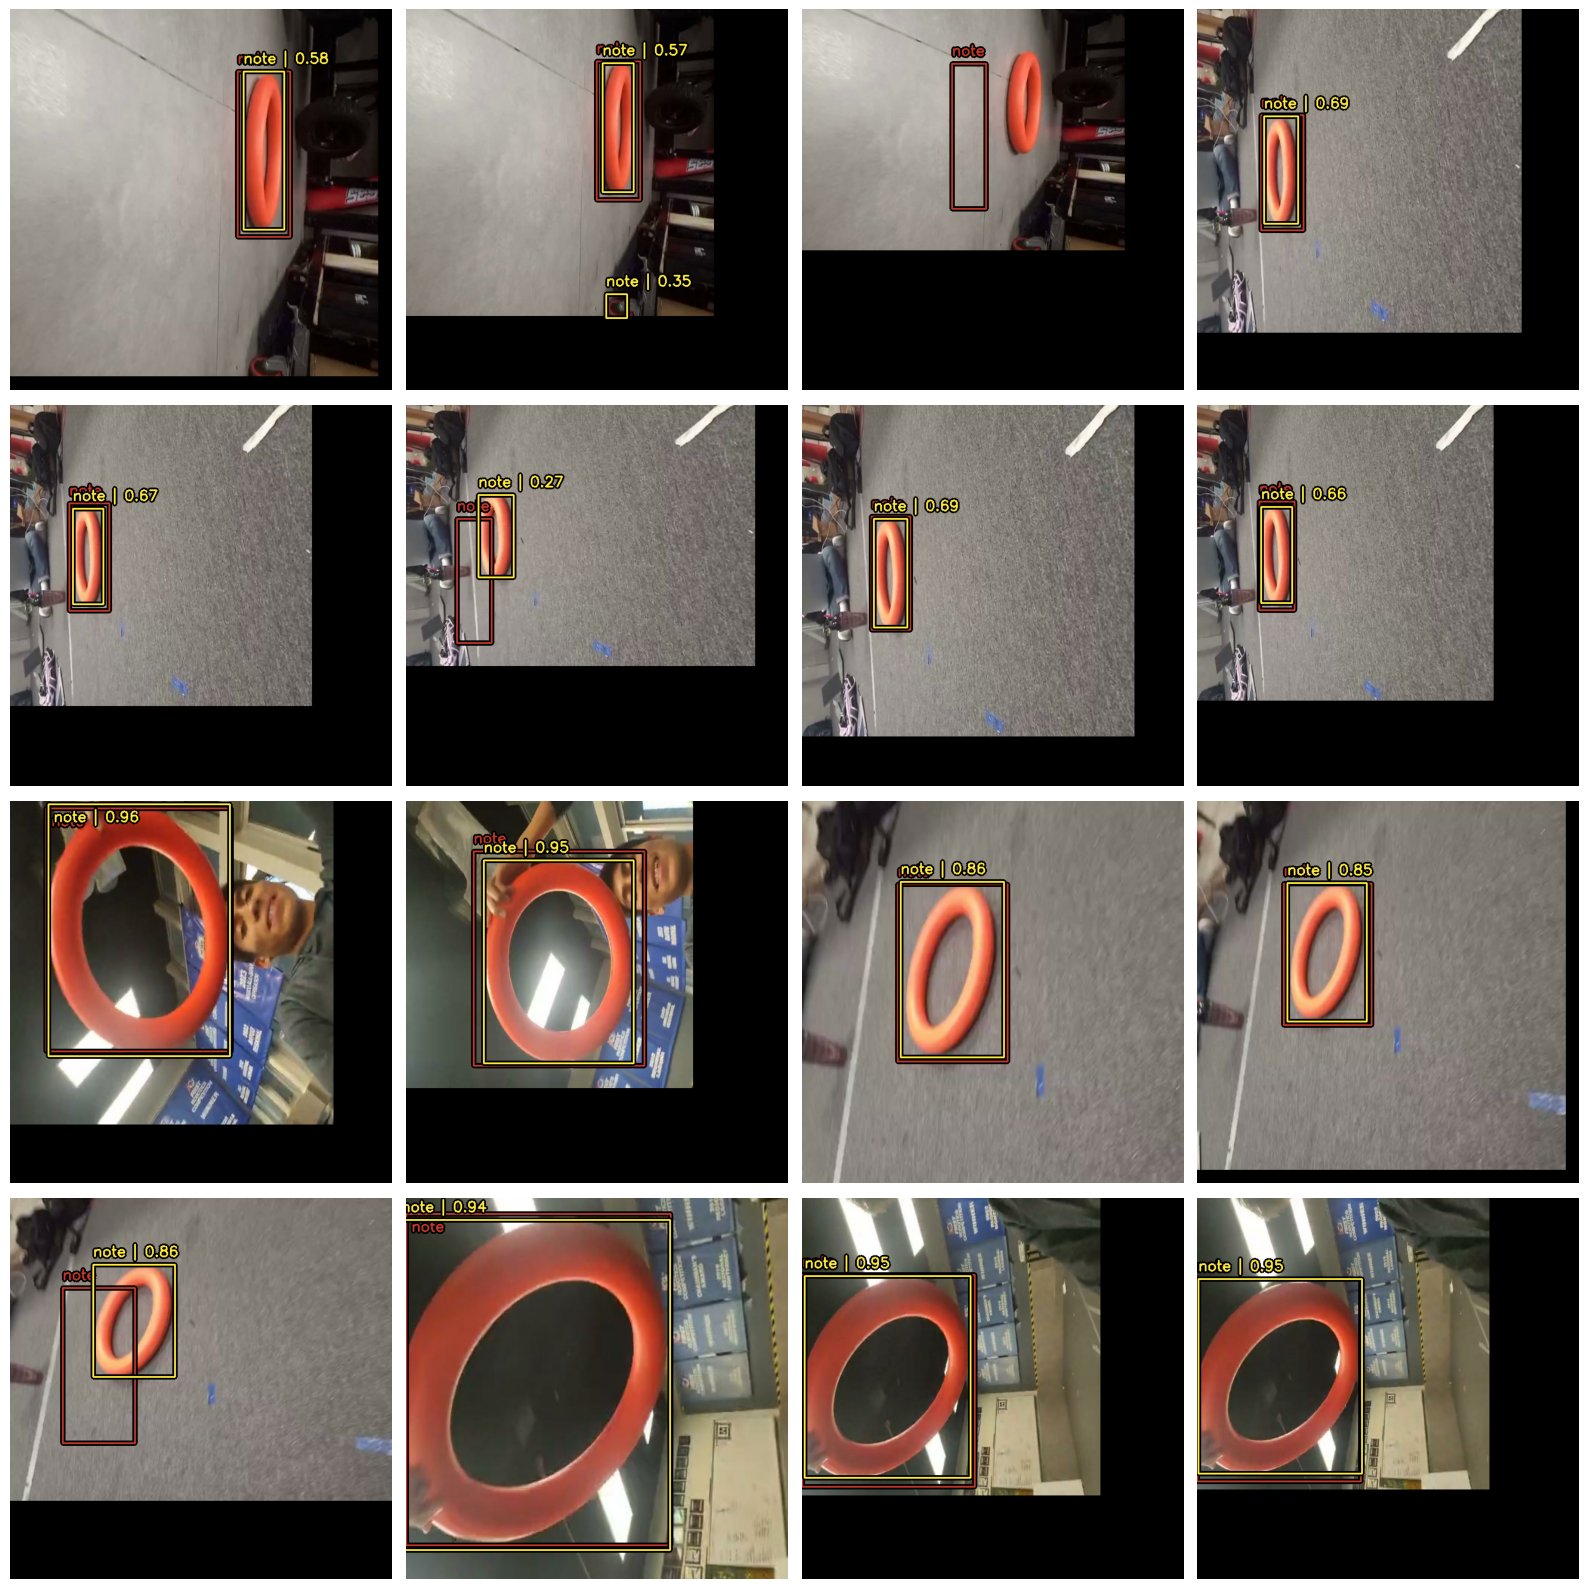

In [35]:
# red -> ground true
# yellow -> prediction

visualize_predict_detections(YOLOV8_model, dataset = test_dataset, bounding_box_format="xyxy")